In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulp import (
    GUROBI_CMD, LpBinary, LpMaximize, LpMinimize, LpProblem, 
    LpStatus, LpVariable, lpSum
)
import scipy as sc
from sklearn.metrics import r2_score
from src.custom_fastkan import FastKAN, FastKANLayer
import src.kan_verification_grapher as kan_verification_grapher
import ssl
import time
from torch import autograd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from typing import List, Dict, Any, Tuple, Optional, Union
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from joblib import Parallel, delayed

In [2]:
def train_mnist():
    ssl._create_default_https_context = ssl._create_unverified_context
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    trainset = torchvision.datasets.MNIST(
        root="./data_mnist", train=True, download=True, transform=transform
    )
    valset = torchvision.datasets.MNIST(
        root="./data_mnist", train=False, download=True, transform=transform
    )
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    valloader = DataLoader(valset, batch_size=64, shuffle=False)

    model = FastKAN([28 * 28, 4, 10], use_base_update=False, use_layernorm=False)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

    criterion = nn.CrossEntropyLoss()
    for epoch in range(4):
        model.train()
        with tqdm(trainloader) as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.view(-1, 28 * 28).to(device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                l2_reg = sum(torch.norm(param, p=2) for param in model.parameters())
                loss = loss + 0.01 * l2_reg
                loss.backward()
                optimizer.step()
                accuracy = (output.argmax(dim=1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for images, labels in valloader:
                images = images.view(-1, 28 * 28).to(device)
                output = model(images)
                val_loss += criterion(output, labels.to(device)).item()
                val_accuracy += (
                    (output.argmax(dim=1) == labels.to(device)).float().mean().item()
                )
        val_loss /= len(valloader)
        val_accuracy /= len(valloader)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}"
        )
    return model


my_kan = train_mnist()

100%|██████████| 938/938 [00:04<00:00, 218.91it/s, accuracy=0.594, loss=1.71, lr=0.001] 


Epoch 1, Val Loss: 1.3882651139216817, Val Accuracy: 0.6297770700636943


100%|██████████| 938/938 [00:04<00:00, 209.46it/s, accuracy=0.688, loss=1.44, lr=0.0008] 


Epoch 2, Val Loss: 0.9141508291481407, Val Accuracy: 0.7589570063694268


100%|██████████| 938/938 [00:04<00:00, 233.63it/s, accuracy=0.875, loss=0.928, lr=0.00064]


Epoch 3, Val Loss: 0.7500890383295192, Val Accuracy: 0.7924960191082803


100%|██████████| 938/938 [00:05<00:00, 170.93it/s, accuracy=0.75, loss=1.13, lr=0.000512]  


Epoch 4, Val Loss: 0.5863296379139469, Val Accuracy: 0.8416600318471338


100%|██████████| 3176/3176 [00:04<00:00, 635.80it/s]


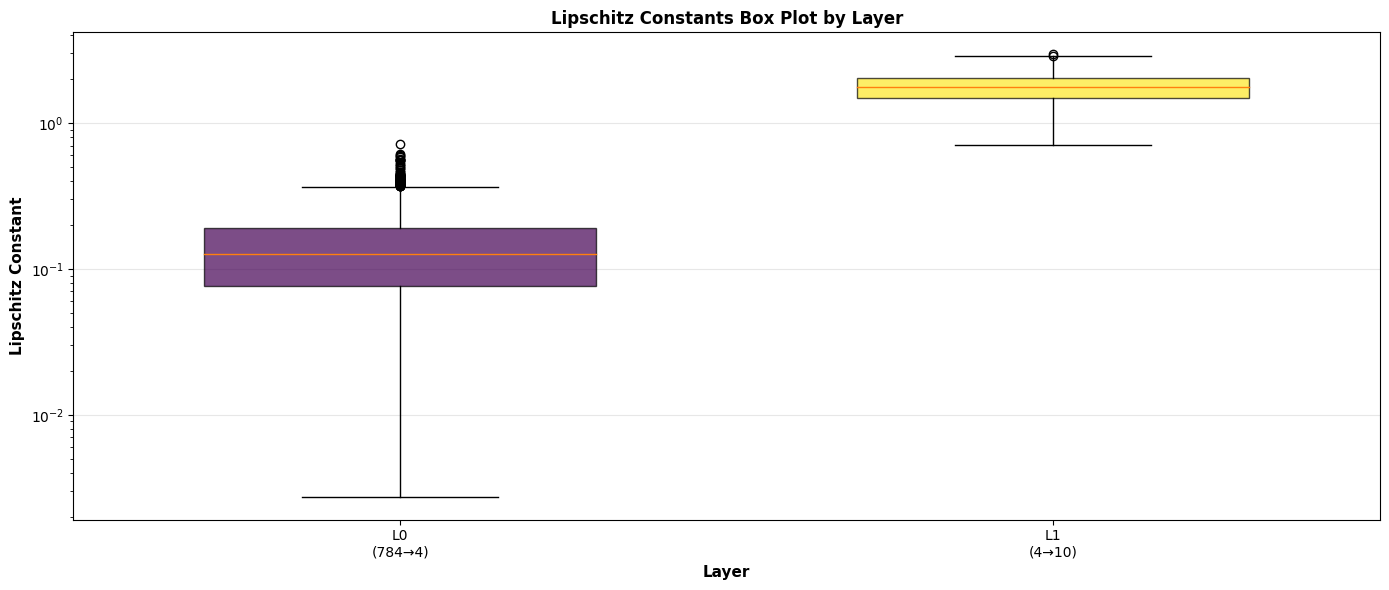

In [3]:
def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_bspline_segments_from_data(x_points, y_points, max_segments):
    n_samples = len(x_points)
    
    # 1. Precompute errors for all possible segments (ONCE)
    errors = np.full((n_samples, n_samples), np.inf)
    for start_idx in range(n_samples-1):
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, n_samples):
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            slope, intercept = fit_line_through_points(x_start, y_start, x_end, y_end)
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # 2. Dynamic programming to find optimal segmentation (ONCE)
    dp_table = np.full((max_segments, n_samples), np.inf)
    backtrack = np.zeros((max_segments, n_samples), dtype=int)
    
    # Base Case: 1 segment
    for j in range(1, n_samples):
        dp_table[0, j] = errors[0, j]
    
    # Recurrence
    for i in range(1, max_segments):
        for j in range(i+1, n_samples):
            # We try breaking at k, where k is between the start of this segment number and current point
            # k is the END of the previous segment
            for k in range(i, j): 
                if dp_table[i-1, k] == np.inf: continue
                if errors[k, j] == np.inf: continue
                
                curr_error = max(dp_table[i-1, k], errors[k, j])
                if curr_error < dp_table[i, j]:
                    dp_table[i, j] = curr_error
                    backtrack[i, j] = k

    # Extract results for EVERY segment count from 1 to max_segments
    results = {}
    for seg_count in range(1, max_segments + 1):
        row_idx = seg_count - 1
        final_error = dp_table[row_idx, n_samples-1]
        if final_error == np.inf:
            results[seg_count] = ([], np.inf)
            continue

        # Reconstruct segments for this specific count using the backtrack table
        segments = []
        curr_seg_end = n_samples - 1
        
        for i in range(row_idx, -1, -1):
            if i > 0:
                prev_seg_end = backtrack[i, curr_seg_end]
            else:
                prev_seg_end = 0
            
            x1, y1 = x_points[prev_seg_end], y_points[prev_seg_end]
            x2, y2 = x_points[curr_seg_end], y_points[curr_seg_end]
            slope, intercept = fit_line_through_points(x1, y1, x2, y2)
            segments.insert(0, (x1, x2, slope, intercept))
            
            curr_seg_end = prev_seg_end
        
        results[seg_count] = (segments, final_error)
        
    return results

def calculate_lipschitz_from_data(x_np, y_np, grid_min, grid_max):
    mask = (x_np >= grid_min) & (x_np <= grid_max)
    x_masked = x_np[mask]
    y_masked = y_np[mask]

    dx = np.diff(x_masked)
    dy = np.diff(y_masked)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    if len(slopes) == 0: return 0.0
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def validate_segments_error(segments, x_high, y_high):
    max_error = 0.0
    for (sx1, sx2, slope, intercept) in segments:
        mask = (x_high >= sx1) & (x_high <= sx2)
        if not np.any(mask):
            continue
        y_real = y_high[mask]
        y_pred = slope * x_high[mask] + intercept
        current_max = np.max(np.abs(y_real - y_pred))
        if current_max > max_error:
            max_error = current_max
            
    return max_error

def process_single_spline(layer_idx, input_idx, output_idx, x_dp, y_dp, x_high, y_high, max_segments, grid_min, grid_max):
    results_low_res = find_bspline_segments_from_data(x_dp, y_dp, max_segments)
    results_validated = {}
    for k, (segs, _) in results_low_res.items():
        true_error = validate_segments_error(segs, x_high, y_high)
        results_validated[k] = (segs, true_error)
    lip = calculate_lipschitz_from_data(x_high, y_high, grid_min, grid_max)
    return (layer_idx, input_idx, output_idx), results_validated, lip

def compute_dp_tables_lipschitz(kan_model, max_segments=15):
    tasks = []
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        all_x_high, all_y_high = layer.get_all_curves(num_pts=1000, num_extrapolate_bins=2)

        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                # Create Low-Res Subsample (25 pts) for DP
                indices = np.linspace(0, 999, 25, dtype=int)
                x_dp = all_x_high[indices]
                y_dp = all_y_high[output_idx, input_idx, indices]
                # Full Res for Validation/Lipschitz
                x_high = all_x_high
                y_high = all_y_high[output_idx, input_idx, :]

                tasks.append((
                    layer_idx, input_idx, output_idx, 
                    x_dp, y_dp,       # Pass low res
                    x_high, y_high,   # Pass high res
                    max_segments, 
                    layer.rbf.grid_min, layer.rbf.grid_max
                ))
    results_list = Parallel(n_jobs=-1)(
        delayed(process_single_spline)(
            l_idx, i_idx, o_idx, x_dp, y_dp, x_high, y_high, max_seg, g_min, g_max
        ) 
        for l_idx, i_idx, o_idx, x_dp, y_dp, x_high, y_high, max_seg, g_min, g_max in tqdm(tasks)
    )
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}

    for key, all_results, lip_const in results_list:
        error_table = {}
        segments_table = {}
        for k, (segs, err) in all_results.items():
            segments_table[k] = segs
            error_table[k] = err
        
        error_tables[key] = error_table
        segments_tables[key] = segments_table
        lipschitz_constants[key] = lip_const

    return error_tables, segments_tables, lipschitz_constants

def plot_lipschitz_comparison_by_layer(lipschitz_constants, kan_model, figsize=(14, 6)):
    num_layers = len(kan_model.layers)
    layer_data = {i: [] for i in range(num_layers)}
    
    for (layer_idx, input_idx, output_idx), lip_const in lipschitz_constants.items():
        if np.isfinite(lip_const):
            layer_data[layer_idx].append(lip_const)
    fig, ax2 = plt.subplots(1, 1, figsize=figsize)
    positions = []
    data_to_plot = []
    labels = []
    for layer_idx in range(num_layers):
        if layer_data[layer_idx]:
            positions.append(layer_idx)
            data_to_plot.append(layer_data[layer_idx])
            layer = kan_model.layers[layer_idx]
            labels.append(f'L{layer_idx}\n({layer.input_dim}→{layer.output_dim})')
    bp = ax2.boxplot(data_to_plot, positions=positions, patch_artist=True,
                     labels=labels, widths=0.6)
    colors = plt.cm.viridis(np.linspace(0, 1, len(data_to_plot)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lipschitz Constant', fontsize=11, fontweight='bold')
    ax2.set_title('Lipschitz Constants Box Plot by Layer', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    return fig

error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(my_kan, 30)
fig2 = plot_lipschitz_comparison_by_layer(lipschitz_constants, my_kan)
plt.show()

In [ ]:
def weight_dp_tables_lipschitz(kan_model, error_tables, segments_tables, lipschitz_constants):
    node_sensitivities = {}
    num_layers = len(kan_model.layers)
    
    # Intialize final layer with all 1's
    final_layer = kan_model.layers[num_layers - 1]
    for out_idx in range(final_layer.output_dim):
        node_sensitivities[(num_layers, out_idx)] = 1.0

    # Calculate sensitivity for the inputs of a layer based on the output layer's sensitivities
    layer_idx = num_layers - 1
    while layer_idx >= 0:
        current_layer = kan_model.layers[layer_idx]
        for input_idx in range(current_layer.input_dim):
            sensitivity_sum = 0.0
            for output_idx in range(current_layer.output_dim):
                lipschitz_constant = lipschitz_constants.get((layer_idx, input_idx, output_idx), 0.0)
                child_node_sensitivity = node_sensitivities[(layer_idx + 1, output_idx)]
                sensitivity_sum += lipschitz_constant * child_node_sensitivity
            node_sensitivities[(layer_idx, input_idx)] = sensitivity_sum
        layer_idx -= 1

    # Weight the error table (just do sensitivities * table)
    weighted_error_tables = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                current_bspline_key = (layer_idx, input_idx, output_idx)
                # The error of a spline is added directly to its destination node (output_idx)
                sensitivity_of_current_output_node = node_sensitivities[(layer_idx + 1, output_idx)]
                weighted_table_for_bspline = {}
                for pair in error_tables[current_bspline_key].items():
                    num_segments = pair[0]
                    error = pair[1]
                    weighted_table_for_bspline[num_segments] = error * sensitivity_of_current_output_node
                weighted_error_tables[current_bspline_key] = weighted_table_for_bspline
    return weighted_error_tables

def plot_error_comparison_by_layer(error_tables, weighted_error_tables, kan_model, max_segments=15, figsize=(14, 8)):
    num_layers = len(kan_model.layers)
    sample_splines = []
    for layer_idx in range(num_layers):
        layer = kan_model.layers[layer_idx]
        # Pick ALL splines in this layer
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                if spline_key in error_tables and spline_key in weighted_error_tables:
                    sample_splines.append(spline_key)
                else:
                    print(f"Warning: Spline {spline_key} not found in tables")
    if not sample_splines:
        print("No valid splines found to plot")
        return None
    num_splines = len(sample_splines)
    cols = min(4, num_splines)
    rows = (num_splines + cols - 1) // cols
    if figsize is None:
        figsize = (5 * cols, 4 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16), squeeze=False)
    axes = axes.flatten()
    for idx, spline_key in enumerate(sample_splines):
        layer_idx, input_idx, output_idx = spline_key
        layer = kan_model.layers[layer_idx]
        original_errors = error_tables[spline_key]
        weighted_errors = weighted_error_tables[spline_key]
        num_segments_list = sorted([k for k in original_errors.keys() if k <= max_segments])
        original_vals = [original_errors[k] for k in num_segments_list if np.isfinite(original_errors[k])]
        weighted_vals = [weighted_errors[k] for k in num_segments_list if np.isfinite(weighted_errors[k])]
        min_len = min(len(num_segments_list), len(original_vals), len(weighted_vals))
        num_segments_list = num_segments_list[:min_len]
        original_vals = original_vals[:min_len]
        weighted_vals = weighted_vals[:min_len]
        ax = axes[idx]
        ax.plot(num_segments_list, original_vals, 'o-', label='Original Error', 
                color='steelblue', linewidth=2, markersize=6)
        ax.plot(num_segments_list, weighted_vals, 's-', label='Weighted Error', 
                color='coral', linewidth=2, markersize=6)
        ax.set_xlabel('Number of Segments', fontsize=10, fontweight='bold')
        ax.set_ylabel('Max Error', fontsize=10, fontweight='bold')
        ax.set_title(f'Layer {layer_idx} ({layer.input_dim}→{layer.output_dim})\n'
                    f'Spline ({input_idx}→{output_idx})', 
                    fontsize=11, fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        if original_vals and weighted_vals and original_vals[-1] > 0:
            ratio = weighted_vals[-1] / original_vals[-1]
            ax.text(0.05, 0.95, f'Weight Ratio: {ratio:.2f}x', 
                   transform=ax.transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    fig.suptitle('Original vs Weighted Error by Layer', fontsize=13, fontweight='bold', y=1.02)
    return fig

weighted_error_tables = weight_dp_tables_lipschitz(my_kan, error_tables, segments_tables, lipschitz_constants)
# fig = plot_error_comparison_by_layer(error_tables, weighted_error_tables, my_kan, max_segments=30)
# plt.show()

In [ ]:
def solve_best_segment_allocation(weighted_error_tables, target_max_error):
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    # Create binary variable x[spline_key, num_segments] for every choice and every spline
    x = {}
    binary_vars_for_splines = {} 
    for spline_key, num_segment_options in weighted_error_tables.items():
        binary_vars_for_splines[spline_key] = []
        for pair in num_segment_options.items():
            k_segments = pair[0]
            error_val = pair[1]
            if np.isinf(error_val):
                continue
            x[(spline_key, k_segments)] = model.addVar(vtype=GRB.BINARY, obj=k_segments)
            binary_vars_for_splines[spline_key].append(x[(spline_key, k_segments)])
    model.update()

    # Make sure we can only pick 1 variable
    for pair in binary_vars_for_splines.items():
        spline_key = pair[0]
        variables = pair[1]
        model.addConstr(gp.quicksum(variables) == 1)
    # Make sure we're under the max error
    total_error_expr = gp.quicksum(weighted_error_tables[s_key][k] * x[(s_key, k)] for s_key, k in x.keys())
    model.addConstr(total_error_expr <= target_max_error)

    # Minimize the total number of segments
    total_segments_expr = gp.quicksum(
        k * x[(s_key, k)] 
        for s_key, k in x.keys()
    )
    model.setObjective(total_segments_expr, GRB.MINIMIZE)

    # Optimize!
    model.optimize()
    optimal_allocation = {}
    if model.status == GRB.OPTIMAL:
        print(f"Optimization successful! Minimum Segments Required: {model.objVal}")
        for (spline_key, k_segments), variable in x.items():
            if variable.X > 0.5:
                optimal_allocation[spline_key] = k_segments
        return optimal_allocation, model.objVal
    elif model.status == GRB.INFEASIBLE:
        print("Model is INFEASIBLE. It is impossible to achieve this low of an error with the available segment options.")
        return None, float('inf')
    else:
        print(f"Optimization ended with status code: {model.status}")
        return None, float('inf')

optimal_allocation, min_error = solve_best_segment_allocation(weighted_error_tables, 0.9)

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 2356 rows, 56520 columns and 113040 nonzeros
Model fingerprint: 0xfc15371f
Variable types: 0 continuous, 56520 integer (56520 binary)
Coefficient statistics:
  Matrix range     [1e-09, 1e+00]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e-01, 1e+00]
Presolve removed 0 rows and 3001 columns
Presolve time: 0.18s
Presolved: 2356 rows, 53519 columns, 107038 nonzeros
Variable types: 0 continuous, 53519 integer (53519 binary)
Found heuristic solution: objective 56519.000000
Found heuristic solution: objective 56518.000000
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...

Concurrent spin time: 0.05s

Solved with dual simplex

Root relaxation: objective 4.903159e+04, 12602 iterations, 0.20 seconds (0.25

In [ ]:
def get_spline_bounds(segments, x_min, x_max):
    y_min, y_max = np.inf, -np.inf
    for (sx1, sx2, slope, intercept) in segments:
        # Find the intersection of the segment domain and input domain
        overlap_start = max(sx1, x_min)
        overlap_end = min(sx2, x_max)
        # If they overlap, evaluate the line at the edges
        if overlap_start <= overlap_end:
            val_start = slope * overlap_start + intercept
            val_end = slope * overlap_end + intercept
            y_min = min(y_min, val_start, val_end)
            y_max = max(y_max, val_start, val_end)
    return y_min, y_max


def propagate_kan_intervals(kan_shape, segments_tables, optimal_allocation, input_lb, input_ub):
    layer_bounds = []
    # Input layer
    current_lb = input_lb
    current_ub = input_ub
    layer_bounds.append((current_lb, current_ub))
    num_transitions = len(kan_shape) - 1

    # Propagate across all layers 
    for layer_idx in range(num_transitions):
        in_dim = kan_shape[layer_idx]
        out_dim = kan_shape[layer_idx + 1]
        next_lb = np.zeros(out_dim)
        next_ub = np.zeros(out_dim)
        for dst in range(out_dim):
            # Min_sum = Sum(Min_parts), Max_sum = Sum(Max_parts)
            total_min = 0.0
            total_max = 0.0
            for src in range(in_dim):
                x_min = current_lb[src]
                x_max = current_ub[src]
                num_segs = optimal_allocation[(layer_idx, src, dst)]
                segs = segments_tables[(layer_idx, src, dst)][num_segs]

                s_min, s_max = get_spline_bounds(segs, x_min, x_max)
                total_min += s_min
                total_max += s_max
            next_lb[dst] = total_min
            next_ub[dst] = total_max
        layer_bounds.append((next_lb, next_ub))
        current_lb, current_ub = next_lb, next_ub
    return layer_bounds

def build_kan_milp_model(kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec):
    model = gp.Model()
    input_dim = kan_shape[0] 
    all_layer_variables = []

    # Create Input Variables
    current_layer_range_variables = []
    for i in range(input_dim):
        input_range_variable = model.addVar(lb=x_min_vec[i], ub=x_max_vec[i])
        current_layer_range_variables.append(input_range_variable)
    all_layer_variables.append(current_layer_range_variables)

    # Build Hidden Layers Sequentially
    num_transitions = len(kan_shape) - 1 # If shape is [784, 32, 10], we have 2 transitions: 0->1 and 1->2
    for layer_idx in range(num_transitions):
        layer_input_dimension = kan_shape[layer_idx]
        layer_output_dimension = kan_shape[layer_idx + 1]
        
        # Initialize output variables for this layer (by creating our list of inputs to the next layer)
        next_layer_input_ranges = []
        for i in range(layer_output_dimension): 
            next_layer_input_ranges.append(gp.LinExpr()) # ex. layer2_neuron_i = layer1_neuron1 + layer1_neuron2 + ... (linear expression!)
        
        for src_idx in range(layer_input_dimension):
            for dst_idx in range(layer_output_dimension):
                # Extract PWL Points
                num_segs = optimal_allocation[(layer_idx, src_idx, dst_idx)]
                seg_data = segments_tables[(layer_idx, src_idx, dst_idx)][num_segs] # table has all possible segment allocations, only extract the optimal one (num_segs)
                x_pts, y_pts = [], []
                for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                    x_pts.append(x1)
                    y_pts.append(slope * x1 + intercept)
                    if idx == len(seg_data) - 1: # Add end point of last segment
                        x_pts.append(x2)
                        y_pts.append(slope * x2 + intercept)

                # Create output variable for each bspline (adding in error)
                approx_error = error_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                error_var = model.addVar(lb=-approx_error, ub=approx_error)
                src_var = current_layer_range_variables[src_idx]
                result_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
                model.addGenConstrPWL(src_var, result_var, x_pts, y_pts) # "The relationship between src_var and result_var must follow the path connected by the dots"
                next_layer_input_ranges[dst_idx] += result_var + error_var # fill in the output linear expressions we defined earlier (for each neuron in the next layer)

        # Create variables for next layer nodes
        next_layer_range_variables = []
        for j in range(layer_output_dimension):
            next_layer_range_variable = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
            model.addConstr(next_layer_range_variable == next_layer_input_ranges[j])
            next_layer_range_variables.append(next_layer_range_variable)
        current_layer_range_variables = next_layer_range_variables
        
        all_layer_variables.append(current_layer_range_variables)

    model.update()
    return model, all_layer_variables

def solve_kan_interval_milp(kan_shape, segments_tables, error_tables, optimal_allocation, output_layer_mip_gap, x_min_vec, x_max_vec):
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, 
        segments_tables, 
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    model, all_layer_variables = build_kan_milp_model(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )

    # Apply the precomputed bounds
    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for neuron_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[neuron_idx]
            var.ub = ubs[neuron_idx]
            
    model.update()
    # Solve only the final layer
    final_layer_vars = all_layer_variables[-1]
    min_bounds = np.zeros(len(final_layer_vars))
    max_bounds = np.zeros(len(final_layer_vars))
    print(f"Starting MILP verification for {len(final_layer_vars)} output neurons...")
    model.setParam('MIPGap', output_layer_mip_gap)
    for i, var in enumerate(final_layer_vars):
        print(f"  Optimizing Output {i}...")
        # Minimize
        model.setObjective(var, GRB.MINIMIZE)
        model.optimize()
        min_bounds[i] = model.ObjBound
        # Maximize
        model.setObjective(var, GRB.MAXIMIZE)
        model.optimize()
        max_bounds[i] = model.ObjBound
    return min_bounds, max_bounds

kan_shape = [my_kan.layers[0].input_dim]
for layer in my_kan.layers:
    kan_shape.append(layer.output_dim)
x_min_vec = np.full(kan_shape[0], -0.5)
x_max_vec = np.full(kan_shape[0], 0.5)

hidden_layer_mip_gap = 0.5
output_layer_mip_gap = 0.05
min_outputs, max_outputs = solve_kan_interval_milp(
    kan_shape,
    segments_tables, 
    error_tables,
    optimal_allocation, 
    output_layer_mip_gap,
    x_min_vec, 
    x_max_vec
)

print("Minimum Output Bounds:", min_outputs)
print("Maximum Output Bounds:", max_outputs)

KeyError: (0, 0, 3)

# Quick Tests

In [46]:
my_kan = train_mnist()

100%|██████████| 938/938 [00:05<00:00, 161.36it/s, accuracy=0.688, loss=1.29, lr=0.001] 


Epoch 1, Val Loss: 1.1167454487958532, Val Accuracy: 0.7314888535031847


100%|██████████| 938/938 [00:05<00:00, 180.24it/s, accuracy=0.906, loss=0.811, lr=0.0008]


Epoch 2, Val Loss: 0.7079022923472581, Val Accuracy: 0.7977707006369427


100%|██████████| 938/938 [00:05<00:00, 179.45it/s, accuracy=0.781, loss=0.865, lr=0.00064]


Epoch 3, Val Loss: 0.6799440811014479, Val Accuracy: 0.7985668789808917


100%|██████████| 938/938 [00:05<00:00, 170.07it/s, accuracy=0.75, loss=1.06, lr=0.000512]  


Epoch 4, Val Loss: 0.5461445897817612, Val Accuracy: 0.8434514331210191


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import *
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulp import (
    GUROBI_CMD,
    LpBinary,
    LpMaximize,
    LpMinimize,
    LpProblem,
    LpStatus,
    LpVariable,
    lpSum,
)
import scipy as sc
from sklearn.metrics import r2_score
import ssl
import time
from torch import autograd
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import gurobipy as gp
from gurobipy import GRB
from joblib import Parallel, delayed  # Added for parallelization

# --- 1. KAN Model Definition (Modified for Speed) ---

class SplineLinear(nn.Linear):
    def __init__(
        self, in_features: int, out_features: int, init_scale: float = 0.1, **kw
    ) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)


class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.0,
        grid_max: float = 2.0,
        num_grids: int = 8,
        denominator: float = None,
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-(((x[..., None] - self.grid) / self.denominator) ** 2))


class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.0,
        grid_max: float = 2.0,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = True,
        base_activation=F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert (
                input_dim > 1
            ), "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(
            input_dim * num_grids, output_dim, spline_weight_init_scale
        )
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret

    # OPTIMIZATION: Vectorized curve calculation for the entire layer
    def get_all_curves(self, num_pts: int = 1000, num_extrapolate_bins: int = 2):
        """
        Returns:
            x_vals: numpy array of shape (num_pts,)
            y_vals: numpy array of shape (output_dim, input_dim, num_pts)
        """
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        
        # 1. Generate X vector once
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts,
            device=self.spline_linear.weight.device
        )
        
        # 2. Compute Basis for X (num_pts, num_grids)
        basis = self.rbf(x) 
        
        # 3. Vectorized Spline Calculation
        # Weights shape: (out_dim, in_dim * num_grids) -> Reshape to (out_dim, in_dim, num_grids)
        w = self.spline_linear.weight.view(self.output_dim, self.input_dim, ng)
        
        # Einstein Summation:
        # b=basis (points, grid), w=weights (out, in, grid) -> Result (out, in, points)
        # Note: We do calculations in float64 for better precision during verification setup if possible, 
        # but here we stick to model dtype
        with torch.no_grad():
             y = torch.einsum('pg, oig -> oip', basis, w)
             
        return x.cpu().numpy(), y.cpu().numpy()

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2,
    ):
        # Kept for backward compatibility if needed, but not used in optimized pipeline
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts,
        )
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y


class FastKAN(nn.Module):
    def __init__(
        self,
        layers_hidden: List[int],
        grid_min: float = -2.0,
        grid_max: float = 2.0,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = True,
        base_activation=F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.use_layernorm = use_layernorm
        self.layers = nn.ModuleList(
            [
                FastKANLayer(
                    in_dim,
                    out_dim,
                    grid_min=grid_min,
                    grid_max=grid_max,
                    num_grids=num_grids,
                    use_base_update=use_base_update,
                    use_layernorm=use_layernorm,
                    base_activation=base_activation,
                    spline_weight_init_scale=spline_weight_init_scale,
                )
                for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:])
            ]
        )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x, use_layernorm=self.use_layernorm)
        return x

# --- 2. Spline Fitting Logic (Optimized) ---

def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept


def find_bspline_segments_from_data(x_points, y_points, max_segments):
    """
    Optimized version that takes numpy arrays directly instead of querying the layer.
    """
    n_samples = len(x_points)

    # 1. Precompute errors for all possible segments (ONCE)
    errors = np.full((n_samples, n_samples), np.inf)
    
    # We can optimize this loop slightly, but for 25 points it's negligible compared to Gurobi
    for start_idx in range(n_samples - 1):
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, n_samples):
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            slope, intercept = fit_line_through_points(x_start, y_start, x_end, y_end)
            
            # Vectorized error check for this segment
            segment_x = x_points[start_idx : end_idx + 1]
            segment_y = y_points[start_idx : end_idx + 1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error

    # 2. Dynamic programming
    dp_table = np.full((max_segments, n_samples), np.inf)
    backtrack = np.zeros((max_segments, n_samples), dtype=int)

    # Base Case: 1 segment
    for j in range(1, n_samples):
        dp_table[0, j] = errors[0, j]

    # Recurrence
    for i in range(1, max_segments):
        for j in range(i + 1, n_samples):
            for k in range(i, j):
                if dp_table[i - 1, k] == np.inf:
                    continue
                if errors[k, j] == np.inf:
                    continue

                curr_error = max(dp_table[i - 1, k], errors[k, j])
                if curr_error < dp_table[i, j]:
                    dp_table[i, j] = curr_error
                    backtrack[i, j] = k

    # Extract results
    results = {}
    for seg_count in range(1, max_segments + 1):
        row_idx = seg_count - 1
        final_error = dp_table[row_idx, n_samples - 1]
        if final_error == np.inf:
            results[seg_count] = ([], np.inf)
            continue

        segments = []
        curr_seg_end = n_samples - 1

        for i in range(row_idx, -1, -1):
            if i > 0:
                prev_seg_end = backtrack[i, curr_seg_end]
            else:
                prev_seg_end = 0

            x1, y1 = x_points[prev_seg_end], y_points[prev_seg_end]
            x2, y2 = x_points[curr_seg_end], y_points[curr_seg_end]
            slope, intercept = fit_line_through_points(x1, y1, x2, y2)
            segments.insert(0, (x1, x2, slope, intercept))

            curr_seg_end = prev_seg_end

        results[seg_count] = (segments, final_error)

    return results

def calculate_lipschitz_from_data(x_np, y_np, grid_min, grid_max):
    mask = (x_np >= grid_min) & (x_np <= grid_max)
    x_masked = x_np[mask]
    y_masked = y_np[mask]

    dx = np.diff(x_masked)
    dy = np.diff(y_masked)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    if len(slopes) == 0: return 0.0
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

# Helper function for Parallel execution
def process_single_spline(layer_idx, input_idx, output_idx, x_pts, y_pts, max_segments, grid_min, grid_max):
    results = find_bspline_segments_from_data(x_pts, y_pts, max_segments)
    lip = calculate_lipschitz_from_data(x_pts, y_pts, grid_min, grid_max)
    return (layer_idx, input_idx, output_idx), results, lip

def compute_dp_tables_lipschitz(kan_model, max_segments=15):
    # OPTIMIZATION: Parallel Processing
    tasks = []
    
    print("Preparing spline tasks (Vectorized fetch)...")
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        
        # Get all curves for this layer at once (Vectorized on GPU/CPU)
        # Using 25 samples as per original code
        all_x, all_y = layer.get_all_curves(num_pts=25, num_extrapolate_bins=2)
        # We also need a higher resolution for Lipschitz calculation? 
        # The original code re-ran plot_curve with 1000 points. 
        # For speed, let's use a higher resolution (1000) for both, then subsample for DP.
        
        all_x_high, all_y_high = layer.get_all_curves(num_pts=1000, num_extrapolate_bins=2)

        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                # Subsample for DP (approx 25 points)
                indices = np.linspace(0, 999, 25, dtype=int)
                x_dp = all_x_high[indices]
                y_dp = all_y_high[output_idx, input_idx, indices]
                
                # Full res for Lipschitz
                x_lip = all_x_high
                y_lip = all_y_high[output_idx, input_idx, :]
                
                tasks.append((
                    layer_idx, input_idx, output_idx, 
                    x_dp, y_dp, 
                    max_segments, 
                    layer.rbf.grid_min, layer.rbf.grid_max
                ))

    print(f"Parallelizing {len(tasks)} spline fits on all available cores...")
    
    # Run in parallel using joblib
    # n_jobs=-1 uses all available CPU cores
    results_list = Parallel(n_jobs=-1)(
        delayed(process_single_spline)(
            l_idx, i_idx, o_idx, x_dp, y_dp, max_seg, g_min, g_max
        ) 
        for l_idx, i_idx, o_idx, x_dp, y_dp, max_seg, g_min, g_max in tqdm(tasks)
    )

    print("Aggregating results...")
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}

    for key, all_results, lip_const in results_list:
        error_table = {}
        segments_table = {}
        for k, (segs, err) in all_results.items():
            segments_table[k] = segs
            error_table[k] = err
        
        error_tables[key] = error_table
        segments_tables[key] = segments_table
        lipschitz_constants[key] = lip_const

    return error_tables, segments_tables, lipschitz_constants

# --- 3. Sensitivity & Weighting Logic (Unchanged) ---

def weight_dp_tables_lipschitz(
    kan_model, error_tables, segments_tables, lipschitz_constants
):
    node_sensitivities = {}
    num_layers = len(kan_model.layers)

    final_layer = kan_model.layers[num_layers - 1]
    for out_idx in range(final_layer.output_dim):
        node_sensitivities[(num_layers, out_idx)] = 1.0

    layer_idx = num_layers - 1
    while layer_idx >= 0:
        current_layer = kan_model.layers[layer_idx]
        for input_idx in range(current_layer.input_dim):
            sensitivity_sum = 0.0
            for output_idx in range(current_layer.output_dim):
                lipschitz_constant = lipschitz_constants.get(
                    (layer_idx, input_idx, output_idx), 0.0
                )
                child_node_sensitivity = node_sensitivities[(layer_idx + 1, output_idx)]
                sensitivity_sum += lipschitz_constant * child_node_sensitivity
            node_sensitivities[(layer_idx, input_idx)] = sensitivity_sum
        layer_idx -= 1

    weighted_error_tables = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                current_bspline_key = (layer_idx, input_idx, output_idx)
                sensitivity_of_current_output_node = node_sensitivities[
                    (layer_idx + 1, output_idx)
                ]
                weighted_table_for_bspline = {}
                for pair in error_tables[current_bspline_key].items():
                    num_segments = pair[0]
                    error = pair[1]
                    weighted_table_for_bspline[num_segments] = (
                        error * sensitivity_of_current_output_node
                    )
                weighted_error_tables[current_bspline_key] = weighted_table_for_bspline
    return weighted_error_tables


def solve_best_segment_allocation(weighted_error_tables, target_max_error):
    model = gp.Model()
    model.setParam("OutputFlag", 0) # Silence Gurobi output for this part
    
    x = {}
    binary_vars_for_splines = {}
    for spline_key, num_segment_options in weighted_error_tables.items():
        binary_vars_for_splines[spline_key] = []
        for pair in num_segment_options.items():
            k_segments = pair[0]
            error_val = pair[1]
            if np.isinf(error_val):
                continue
            x[(spline_key, k_segments)] = model.addVar(vtype=GRB.BINARY, obj=k_segments)
            binary_vars_for_splines[spline_key].append(x[(spline_key, k_segments)])
    model.update()

    for pair in binary_vars_for_splines.items():
        spline_key = pair[0]
        variables = pair[1]
        model.addConstr(gp.quicksum(variables) == 1)
        
    total_error_expr = gp.quicksum(
        weighted_error_tables[s_key][k] * x[(s_key, k)] for s_key, k in x.keys()
    )
    model.addConstr(total_error_expr <= target_max_error)

    total_segments_expr = gp.quicksum(k * x[(s_key, k)] for s_key, k in x.keys())
    model.setObjective(total_segments_expr, GRB.MINIMIZE)

    model.optimize()
    optimal_allocation = {}
    if model.status == GRB.OPTIMAL:
        print(f"Segment Allocation: Optimization successful! Segments used: {model.objVal}")
        for (spline_key, k_segments), variable in x.items():
            if variable.X > 0.5:
                optimal_allocation[spline_key] = k_segments
        return optimal_allocation, model.objVal
    elif model.status == GRB.INFEASIBLE:
        print("Segment Allocation: Model is INFEASIBLE.")
        return None, float("inf")
    else:
        print(f"Segment Allocation: Ended with status code: {model.status}")
        return None, float("inf")


# --- 4. MILP Verification Logic ---

def get_spline_bounds(segments, x_min, x_max):
    y_min, y_max = np.inf, -np.inf
    for sx1, sx2, slope, intercept in segments:
        overlap_start = max(sx1, x_min)
        overlap_end = min(sx2, x_max)
        if overlap_start <= overlap_end:
            val_start = slope * overlap_start + intercept
            val_end = slope * overlap_end + intercept
            y_min = min(y_min, val_start, val_end)
            y_max = max(y_max, val_start, val_end)
    return y_min, y_max


def propagate_kan_intervals(
    kan_shape, segments_tables, optimal_allocation, input_lb, input_ub
):
    layer_bounds = []
    current_lb = input_lb
    current_ub = input_ub
    layer_bounds.append((current_lb, current_ub))
    num_transitions = len(kan_shape) - 1

    for layer_idx in range(num_transitions):
        in_dim = kan_shape[layer_idx]
        out_dim = kan_shape[layer_idx + 1]
        next_lb = np.zeros(out_dim)
        next_ub = np.zeros(out_dim)
        for dst in range(out_dim):
            total_min = 0.0
            total_max = 0.0
            for src in range(in_dim):
                x_min = current_lb[src]
                x_max = current_ub[src]
                num_segs = optimal_allocation[(layer_idx, src, dst)]
                segs = segments_tables[(layer_idx, src, dst)][num_segs]

                s_min, s_max = get_spline_bounds(segs, x_min, x_max)
                total_min += s_min
                total_max += s_max
            next_lb[dst] = total_min
            next_ub[dst] = total_max
        layer_bounds.append((next_lb, next_ub))
        current_lb, current_ub = next_lb, next_ub
    return layer_bounds


def build_kan_milp_model(
    kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec
):
    model = gp.Model()
    input_dim = kan_shape[0]
    all_layer_variables = []

    current_layer_range_variables = []
    for i in range(input_dim):
        input_range_variable = model.addVar(lb=x_min_vec[i], ub=x_max_vec[i])
        current_layer_range_variables.append(input_range_variable)
    all_layer_variables.append(current_layer_range_variables)

    num_transitions = len(kan_shape) - 1
    for layer_idx in range(num_transitions):
        layer_input_dimension = kan_shape[layer_idx]
        layer_output_dimension = kan_shape[layer_idx + 1]

        next_layer_input_ranges = []
        for i in range(layer_output_dimension):
            next_layer_input_ranges.append(gp.LinExpr())

        for src_idx in range(layer_input_dimension):
            for dst_idx in range(layer_output_dimension):
                num_segs = optimal_allocation[(layer_idx, src_idx, dst_idx)]
                seg_data = segments_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                x_pts, y_pts = [], []
                for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                    x_pts.append(x1)
                    y_pts.append(slope * x1 + intercept)
                    if idx == len(seg_data) - 1:
                        x_pts.append(x2)
                        y_pts.append(slope * x2 + intercept)

                approx_error = error_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                error_var = model.addVar(lb=-approx_error, ub=approx_error)
                src_var = current_layer_range_variables[src_idx]
                result_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
                model.addGenConstrPWL(src_var, result_var, x_pts, y_pts)
                next_layer_input_ranges[dst_idx] += (result_var + error_var)

        next_layer_range_variables = []
        for j in range(layer_output_dimension):
            next_layer_range_variable = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
            model.addConstr(next_layer_range_variable == next_layer_input_ranges[j])
            next_layer_range_variables.append(next_layer_range_variable)
        current_layer_range_variables = next_layer_range_variables

        all_layer_variables.append(current_layer_range_variables)

    model.update()
    return model, all_layer_variables


def solve_kan_interval_milp(
    kan_shape,
    segments_tables,
    error_tables,
    optimal_allocation,
    output_layer_mip_gap,
    x_min_vec,
    x_max_vec,
):
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, segments_tables, optimal_allocation, x_min_vec, x_max_vec
    )
    model, all_layer_variables = build_kan_milp_model(
        kan_shape,
        segments_tables,
        error_tables,
        optimal_allocation,
        x_min_vec,
        x_max_vec,
    )

    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for neuron_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[neuron_idx]
            var.ub = ubs[neuron_idx]

    model.update()
    final_layer_vars = all_layer_variables[-1]
    min_bounds = np.zeros(len(final_layer_vars))
    max_bounds = np.zeros(len(final_layer_vars))
    
    print(f"Starting MILP verification for {len(final_layer_vars)} output neurons...")
    print(f"Using MIP Gap: {output_layer_mip_gap}")
    model.setParam("MIPGap", output_layer_mip_gap)
    
    #for i, var in enumerate(final_layer_vars):
    model.setObjective(var, GRB.MINIMIZE)
    model.optimize()
    if model.status == GRB.OPTIMAL:
        min_bounds = model.ObjBound
    else:
        min_bounds = np.nan
        
    # model.setObjective(var, GRB.MAXIMIZE)
    # model.optimize()
    # if model.status == GRB.OPTIMAL:
    #     max_bounds[i] = model.ObjBound
    # else:
    #     max_bounds[i] = np.nan
            
    return min_bounds#, max_bounds


# --- 5. Main Execution Block ---

# Create model


# Optional: Load weights or train here if needed
# 1. Compute Splines (Faster now!)
error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(
    my_kan, 30
)

# 2. Compute Sensitivities
weighted_error_tables = weight_dp_tables_lipschitz(
    my_kan, error_tables, segments_tables, lipschitz_constants
)

# 3. Solve Allocation
optimal_allocation, min_error = solve_best_segment_allocation(
    weighted_error_tables, 0.9
)

# 4. Verify
kan_shape = [my_kan.layers[0].input_dim]
for layer in my_kan.layers:
    kan_shape.append(layer.output_dim)
    
x_min_vec = np.full(kan_shape[0], -0.5)
x_max_vec = np.full(kan_shape[0], 0.5)

# OPTIMIZATION: Relaxed Gap
output_layer_mip_gap = 0.05  # 5% Gap (Much faster than 1e-4)

if optimal_allocation is not None:
    min_outputs = solve_kan_interval_milp(
        kan_shape,
        segments_tables,
        error_tables,
        optimal_allocation,
        output_layer_mip_gap,
        x_min_vec,
        x_max_vec,
    )

    print("Minimum Output Bounds:", min_outputs)
    #print("Maximum Output Bounds:", max_outputs)
else:
    print("Could not proceed to verification due to allocation failure.")

Preparing spline tasks (Vectorized fetch)...
Parallelizing 3176 spline fits on all available cores...


100%|██████████| 3176/3176 [00:02<00:00, 1142.41it/s]


Aggregating results...
Segment Allocation: Optimization successful! Segments used: 70436.0
Starting MILP verification for 10 output neurons...
Using MIP Gap: 0.05
Set parameter MIPGap to value 0.05
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
MIPGap  0.05

Optimize a model with 14 rows, 7150 columns and 6366 nonzeros
Model fingerprint: 0x8705661d
Model has 3176 simple general constraints
  3176 PWL
Variable types: 7150 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [9e-10, 4e+01]
  RHS range        [0e+00, 0e+00]
  PWLCon x range   [3e-03, 3e+00]
  PWLCon y range   [1e-07, 2e+00]
Presolve added 6360 rows and 10164 columns
Presolve time: 0.03s
Presolved: 6374 rows, 17314 columns, 46905 nonzeros
Presolved model has 3153 SOS con

In [51]:
def solve_single_neuron(
    neuron_idx, 
    kan_shape, 
    segments_tables, 
    error_tables, 
    optimal_allocation, 
    precomputed_bounds, 
    x_min_vec, 
    x_max_vec, 
    mip_gap,
    pruning_threshold
):
    """Worker function for parallel processing"""
    # Rebuild model locally
    model, all_layer_variables = build_kan_milp_model(
        kan_shape, segments_tables, error_tables, optimal_allocation, 
        x_min_vec, x_max_vec, pruning_threshold
    )
    
    # --- FIX 1: Prevent CPU Thrashing ---
    # We are already parallelizing via Joblib (Process level). 
    # We must restrict Gurobi to 1 thread per process.
    model.setParam("Threads", 1) 
    
    # --- FIX 2: Prevent Infinite Gap Loop ---
    # MIPFocus=0 (Balanced) ensures we find a feasible solution (Upper Bound)
    # so the MIPGap can actually be calculated and the solver can terminate.
    model.setParam("MIPFocus", 0) 
    
    # Safety Net: If it's still hard, stop after 60s and take the best bound found
    model.setParam("TimeLimit", 60) 

    # Apply precomputed bounds
    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for n_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[n_idx]
            var.ub = ubs[n_idx]
            
    final_layer_vars = all_layer_variables[-1]
    target_var = final_layer_vars[neuron_idx]
    
    model.setParam("MIPGap", mip_gap)
    
    # Minimize
    model.setObjective(target_var, GRB.MINIMIZE)
    model.optimize()
    
    # Return the Bound (Guaranteed Minimum), not the Objective (Feasible Solution)
    # This remains valid even if TimeLimit is hit.
    return model.ObjBound

def solve_kan_interval_milp(
    kan_shape,
    segments_tables,
    error_tables,
    optimal_allocation,
    output_layer_mip_gap,
    x_min_vec,
    x_max_vec,
    pruning_threshold=1e-3
):
    # 1. Precompute Interval Bounds
    print("Precomputing layer bounds...")
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, segments_tables, optimal_allocation, x_min_vec, x_max_vec
    )

    num_outputs = kan_shape[-1]
    # Check CPU count to avoid over-subscribing even with Joblib
    import multiprocessing
    n_jobs = min(num_outputs, multiprocessing.cpu_count())

    print(f"Starting Parallel MILP verification for {num_outputs} output neurons...")
    print(f"  - Pruning Threshold: {pruning_threshold}")
    print(f"  - Parallel Jobs: {n_jobs} (Threads per job: 1)")

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(solve_single_neuron)(
            i, 
            kan_shape, 
            segments_tables, 
            error_tables, 
            optimal_allocation, 
            precomputed_bounds, 
            x_min_vec, 
            x_max_vec, 
            output_layer_mip_gap,
            pruning_threshold
        ) 
        for i in range(num_outputs)
    )
    
    return np.array(results)

# --- EXECUTION ---
import time
start_t = time.time()

# Ensure strict bounds for inputs
kan_shape = [my_kan.layers[0].input_dim]
for layer in my_kan.layers:
    kan_shape.append(layer.output_dim)
x_min_vec = np.full(kan_shape[0], -0.5) 
x_max_vec = np.full(kan_shape[0], 0.5)

output_layer_mip_gap = 1e-4

min_outputs = solve_kan_interval_milp(
    kan_shape,
    segments_tables,
    error_tables,
    optimal_allocation,
    output_layer_mip_gap,
    x_min_vec,
    x_max_vec,
    pruning_threshold=5e-3
)

end_t = time.time()
print(f"\nVerification Complete in {end_t - start_t:.2f} seconds.")
print("Minimum Output Bounds:", min_outputs)

Precomputing layer bounds...
Starting Parallel MILP verification for 10 output neurons...
  - Pruning Threshold: 0.005
  - Parallel Jobs: 10 (Threads per job: 1)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


Set parameter Username
Set parameter LicenseID to value 2620375
Academic license - for non-commercial use only - expires 2026-02-10
Set parameter MIPFocus to value 3
Set parameter Method to value 1
Set parameter Presolve to value 2
Set parameter Threads to value 1
Set parameter MIPFocus to value 0
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.0001
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 1 threads

Non-default parameters:
TimeLimit  60
Method  1
Presolve  2
Threads  1

Optimize a model with 14 rows, 7097 columns and 6313 nonzeros
Model fingerprint: 0x30653e4e
Model has 3123 simple general constraints
  3123 PWL
Variable types: 7097 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [9e-10, 4e+01]
  RHS range        [0e+00, 0e+00]
  PWLCon 

[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  1.3min remaining:  3.0min


  3332  2823   -5.87251  400  861          -   -5.87251      -   1.5   10s
  3741  3145   -8.54572  604  563          -   -8.54572      -   1.7   20s
  5221  4100   -4.60514 1344  221          -   -5.41283      -  15.2   55s
  4972  3877 infeasible 1216               -   -5.78583      -  12.0   50s
  4777  3793   -4.95332 1122  181          -   -4.95332      -   2.4   30s
  4122  3373   -5.99706  795  370          -   -5.99706      -   9.0   45s
* 5010  3751            1235      -3.8398116   -5.78583  50.7%  13.8   52s
  5068  4032   -6.27055 1267  257          -   -6.27105      -  12.4   40s
  3967  3244   -5.87251  717  625          -   -5.87251      -   2.0   15s
  4344  3541   -8.54572  906  240          -   -8.54572      -   2.2   25s

Explored 5352 nodes (98545 simplex iterations) in 60.00 seconds (67.66 work units)
Thread count was 1 (of 10 available processors)

Solution count 0

Time limit reached
Best objective -, best bound -5.412830412388e+00, gap -
  5113  3798   -5.78583 

[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  1.5min remaining:  1.5min


  4535  3668   -8.21081 1001  411          -   -8.54572      -   7.0   31s
  4531  3646   -5.99706  999  164          -   -5.99706      -  13.3   55s
  4954  3899   -4.51151 1211  311          -   -4.95332      -  11.8   41s
  5379  4215   -4.22267 1422  109          -   -6.27105      -  23.9   50s
  4814  3852   -4.85736 1141  234          -   -8.54572      -   8.2   35s
  4776  3769   -5.57029 1122  382          -   -5.87251      -   8.8   26s

Explored 4563 nodes (115143 simplex iterations) in 60.00 seconds (71.81 work units)
Thread count was 1 (of 10 available processors)

Solution count 0

Time limit reached
Best objective -, best bound -5.997055530548e+00, gap -
  4994  3926   -4.40097 1231  293          -   -4.95332      -  16.7   46s
  5476  4256   -1.31418 1464  212          -   -6.27105      -  30.8   55s
* 5485  4122            1469      -3.8053521   -6.27105  64.8%  32.1   56s
* 5503  3995            1471      -3.8054468   -6.27105  64.8%  32.0   56s
  5041  4001   -4.62926

[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  1.7min remaining:   43.0s


  5127  4030   -2.99744 1292   89          -   -8.54572      -  18.9   45s
  4910  3859   -5.41092 1189  319          -   -5.87251      -  17.4   36s
  5226  4080   -2.40987 1347  292          -   -4.95332      -  22.8   55s
* 5132  3903            1295      -3.5427108   -8.54572   141%  20.3   46s
  4939  3878   -3.75230 1203  331          -   -5.87251      -  21.3   40s
  5152  3890   -8.18607  959  468   -3.54271   -8.54572   141%  24.1   50s

Explored 5287 nodes (163940 simplex iterations) in 60.00 seconds (80.75 work units)
Thread count was 1 (of 10 available processors)

Solution count 0

Time limit reached
Best objective -, best bound -4.953318715096e+00, gap -
  5332  4080   -2.14008 1399  100          -   -5.87251      -  21.6   45s
  5384  4045   -7.77915 1075  380   -3.54271   -8.54572   141%  24.7   55s
* 5454  3925            1460      -2.1579644   -5.87251   172%  22.0   46s
  5496  3927   -5.49485 1190  626   -2.15796   -5.87251   172%  25.8   50s
  5632  4208   -7.01919

[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  2.1min finished
